In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances

np.random.seed(0)
import os

os.makedirs("figs", exist_ok=True)


In [37]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="HouseValue")

In [38]:
print(X.shape)
print(y.shape)

print(X.columns)

print(X.head())

print(y.head())

print(X.isnull().sum())
print(y.isnull().sum())

(20640, 8)
(20640,)
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='str')
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: HouseValue, dtype: float64
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
0


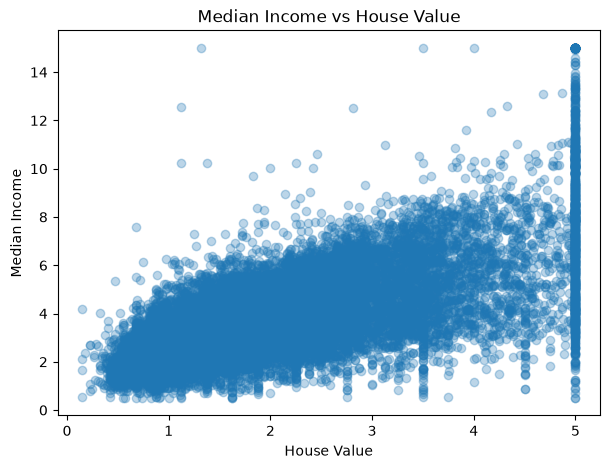

In [39]:
plt.figure(figsize=(7, 5))

plt.scatter(y,X["MedInc"], alpha=0.3)

plt.ylabel("Median Income")
plt.xlabel("House Value")
plt.title("Median Income vs House Value")

plt.savefig("figs/01_medinc_vs_housevalue.png", dpi=150, bbox_inches="tight")
plt.show()

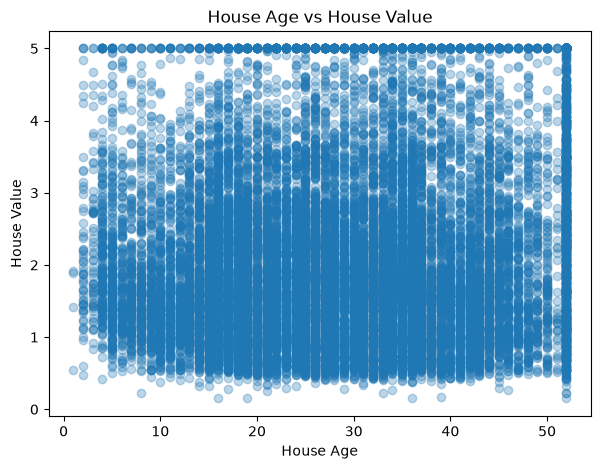

In [40]:
plt.figure(figsize=(7, 5))

plt.scatter(X["HouseAge"], y, alpha=0.3)

plt.xlabel("House Age")
plt.ylabel("House Value")
plt.title("House Age vs House Value")

plt.savefig("figs/02_houseage_vs_housevalue.png", dpi=150, bbox_inches="tight")
plt.show()

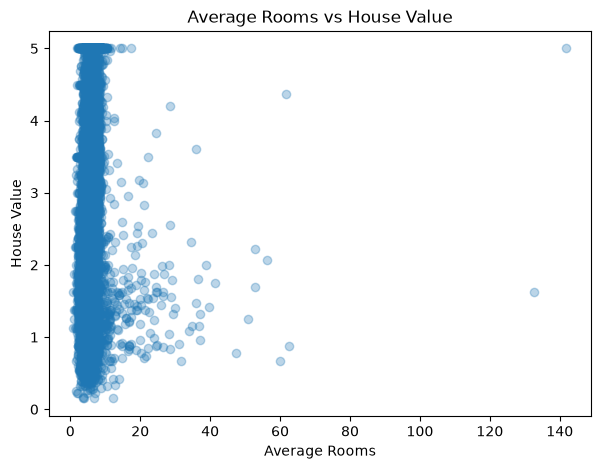

In [41]:
plt.figure(figsize=(7, 5))

plt.scatter(X["AveRooms"], y, alpha=0.3)

plt.xlabel("Average Rooms")
plt.ylabel("House Value")
plt.title("Average Rooms vs House Value")

plt.savefig("figs/03_averooms_vs_housevalue.png", dpi=150, bbox_inches="tight")
plt.show()

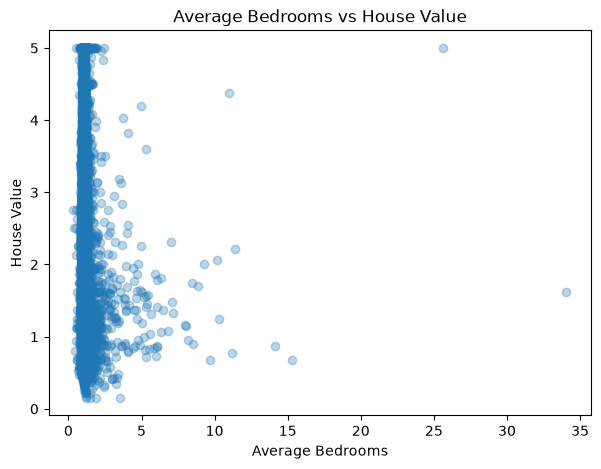

In [42]:
plt.figure(figsize=(7, 5))

plt.scatter(X["AveBedrms"],y,alpha=0.3)

plt.xlabel("Average Bedrooms")
plt.ylabel("House Value")
plt.title("Average Bedrooms vs House Value")

plt.savefig("figs/04_avebedrms_vs_housevalue.png", dpi=150, bbox_inches="tight")
plt.show()

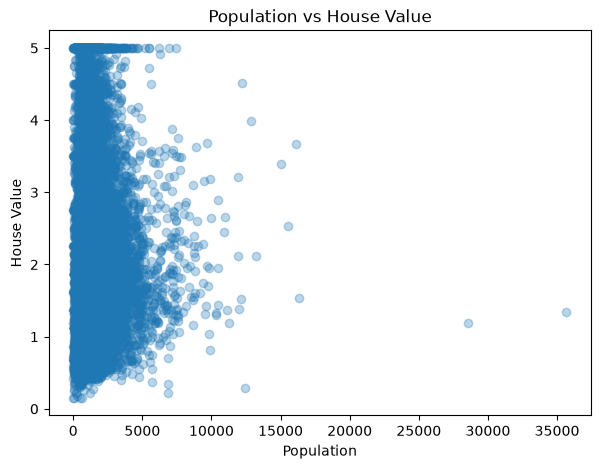

In [43]:
plt.figure(figsize=(7, 5))

plt.scatter(X["Population"], y, alpha=0.3)

plt.xlabel("Population")
plt.ylabel("House Value")
plt.title("Population vs House Value")

plt.savefig("figs/05_population_vs_housevalue.png", dpi=150, bbox_inches="tight")
plt.show()

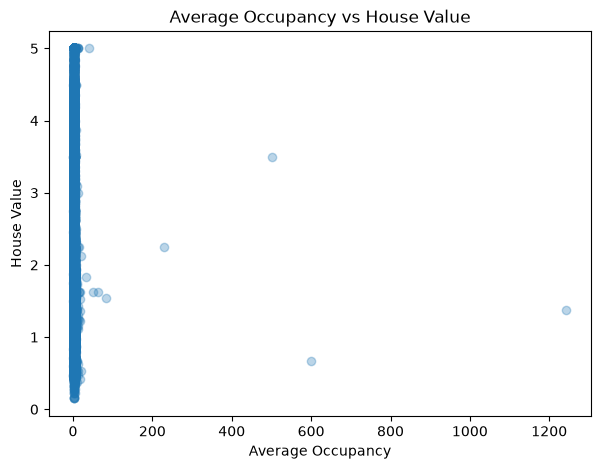

In [44]:
plt.figure(figsize=(7, 5))

plt.scatter(X["AveOccup"], y, alpha=0.3)

plt.xlabel("Average Occupancy")
plt.ylabel("House Value")
plt.title("Average Occupancy vs House Value")

plt.savefig("figs/06_aveoccup_vs_housevalue.png", dpi=150, bbox_inches="tight")
plt.show()

In [45]:
X_task2 = X[["MedInc", "HouseAge"]]

print(X_task2.shape)
print(X_task2.head())

(20640, 2)
   MedInc  HouseAge
0  8.3252      41.0
1  8.3014      21.0
2  7.2574      52.0
3  5.6431      52.0
4  3.8462      52.0


In [46]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_task2, y)
print("Intercept:", lr_model.intercept_)
print("Coefficients:", lr_model.coef_)

print("MedInc coefficient:", lr_model.coef_[0])
print("HouseAge coefficient:", lr_model.coef_[1])

Intercept: -0.10189032759082606
Coefficients: [0.43169191 0.01744134]
MedInc coefficient: 0.43169190754495385
HouseAge coefficient: 0.017441344456555007


c:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


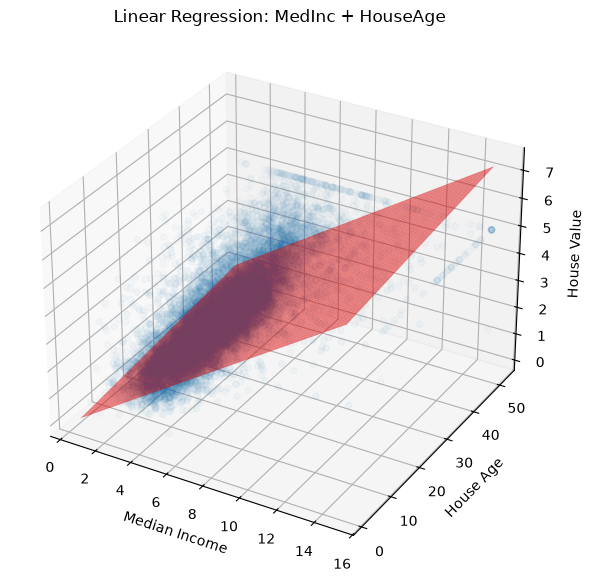

In [47]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Plot actual observations
ax.scatter(
    X_task2["MedInc"],
    X_task2["HouseAge"],
    y,
    alpha=0.2
)

# Create grid of MedInc and HouseAge values
medinc_range = np.linspace(
    X_task2["MedInc"].min(),
    X_task2["MedInc"].max(),
    50
)

houseage_range = np.linspace(
    X_task2["HouseAge"].min(),
    X_task2["HouseAge"].max(),
    50
)

XX, YY = np.meshgrid(
    medinc_range,
    houseage_range
)

# Create input points for prediction
grid = np.column_stack([
    XX.ravel(),
    YY.ravel()
])

# Predict HouseValue on the grid
ZZ = lr_model.predict(grid)
ZZ = ZZ.reshape(XX.shape)

# Plot regression plane
ax.plot_surface(
    XX,
    YY,
    ZZ,
    alpha=0.5,
    color="red"
)

# Labels
ax.set_xlabel("Median Income")
ax.set_ylabel("House Age")
ax.set_zlabel("House Value")
ax.set_title("Linear Regression: MedInc + HouseAge")

plt.savefig("figs/07_lr_3d_medinc_houseage.png", dpi=150, bbox_inches="tight")
plt.show()

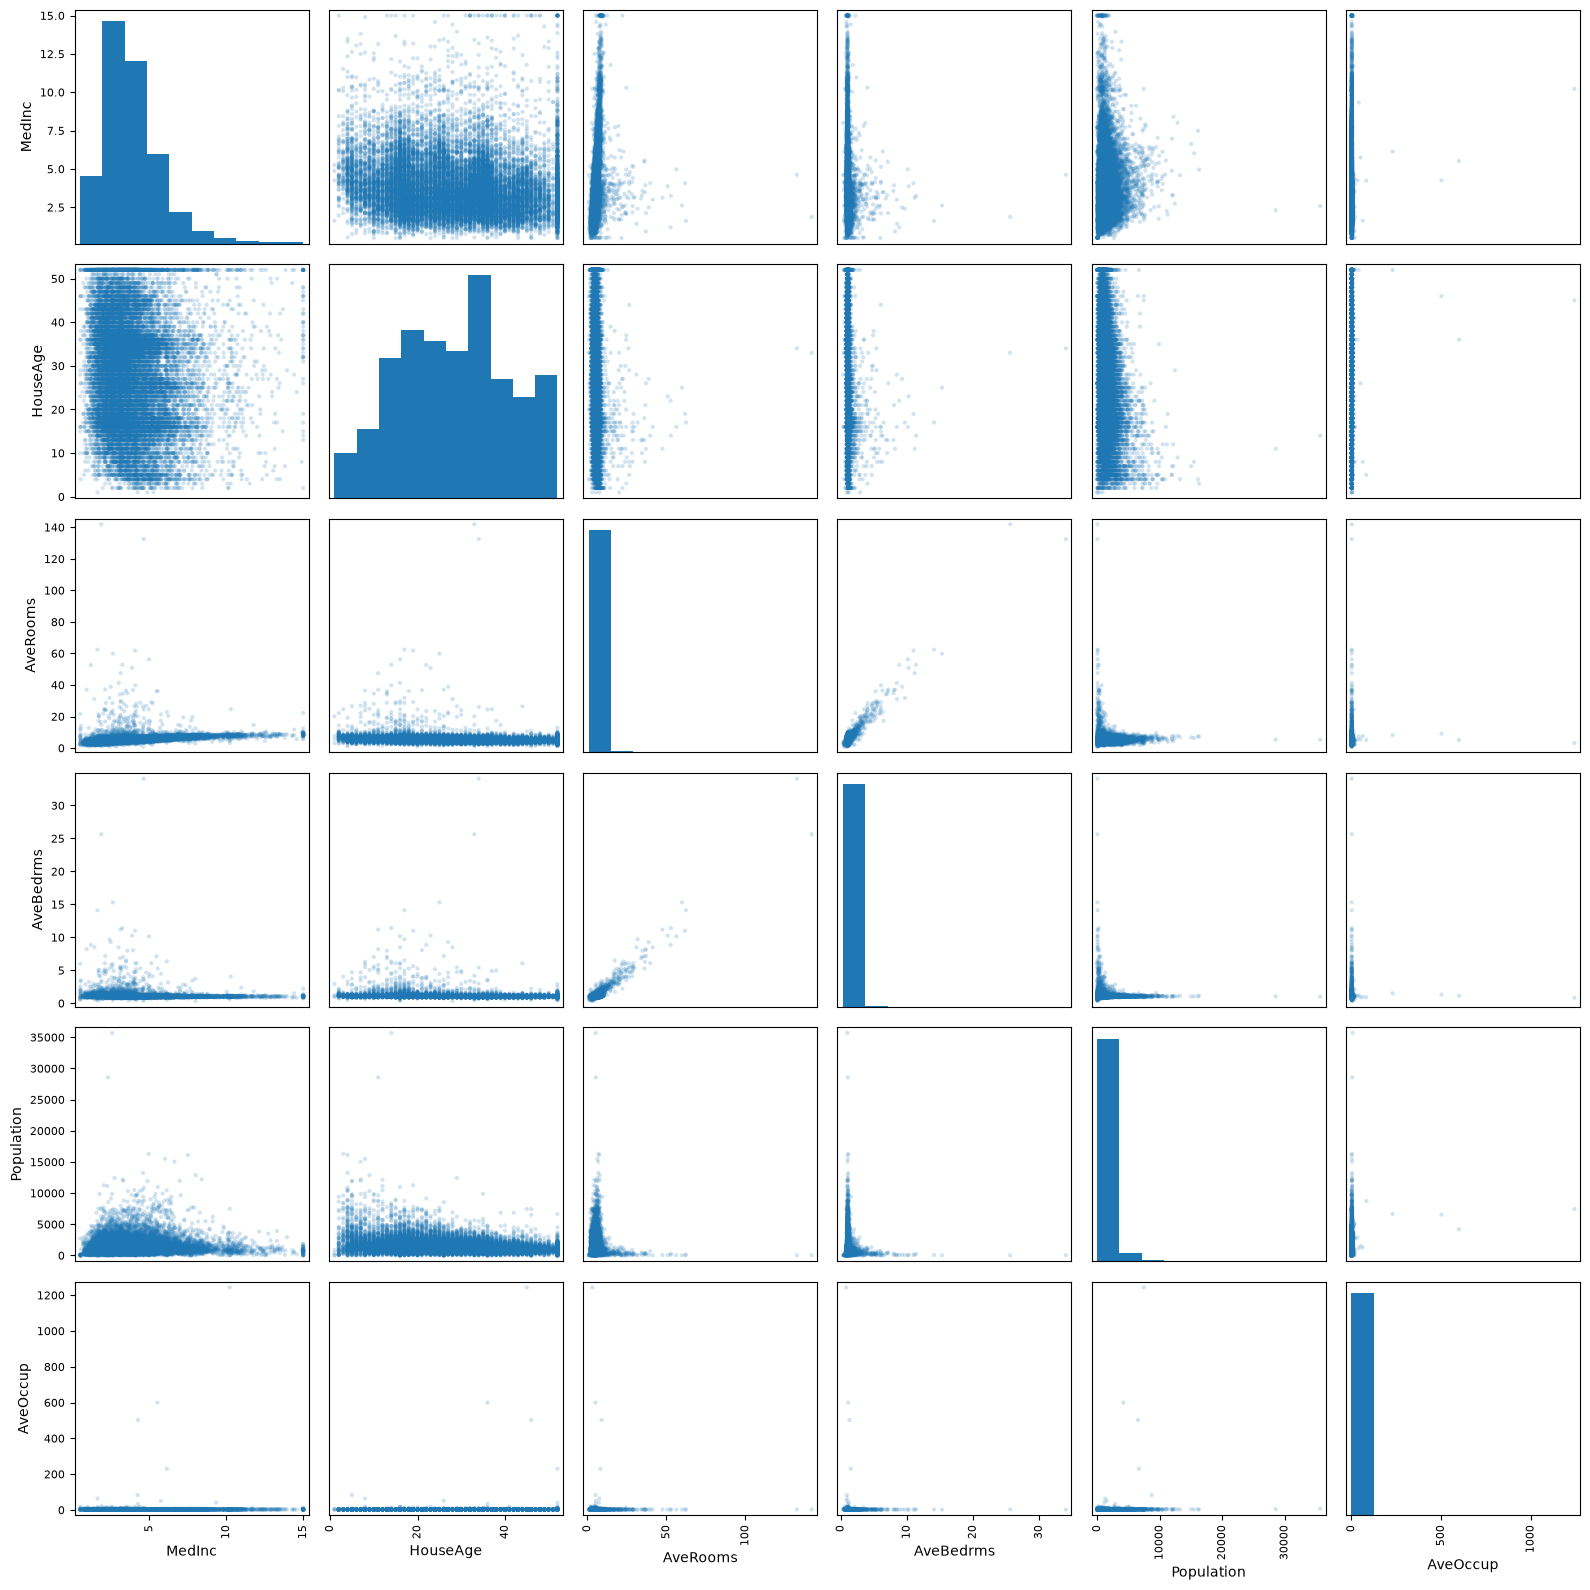

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

features = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup"
]

pd.plotting.scatter_matrix(
    X[features],
    figsize=(16, 16),
    alpha=0.2,
    diagonal="hist"
)

plt.tight_layout()
plt.show()

Intercept: 0.4508557670326787
Coefficient: 0.41793849201896294

HouseValue = 0.4509 + 0.4179 × MedInc


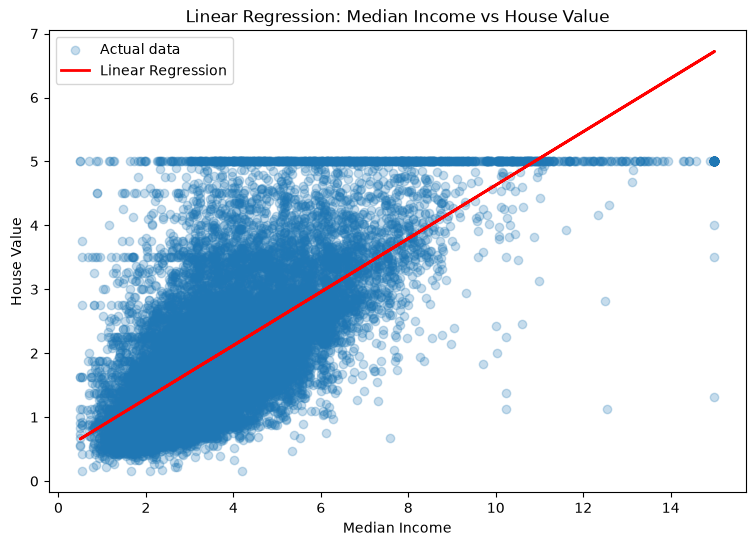

In [49]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Select only MedInc as input
X_lr = X[["MedInc"]]

# Create and fit Linear Regression model
lr_model_1d = LinearRegression()
lr_model_1d.fit(X_lr, y)

# Generate predictions
y_pred_1d = lr_model_1d.predict(X_lr)

# Print the equation
print("Intercept:", lr_model_1d.intercept_)
print("Coefficient:", lr_model_1d.coef_[0])

print(
    f"\nHouseValue = {lr_model_1d.intercept_:.4f} "
    f"+ {lr_model_1d.coef_[0]:.4f} × MedInc"
)

# Plot actual data
plt.figure(figsize=(9, 6))

plt.scatter(
    X["MedInc"],
    y,
    alpha=0.25,
    label="Actual data"
)

# Plot Linear Regression line
plt.plot(
    X["MedInc"],
    y_pred_1d,
    color="red",
    linewidth=2,
    label="Linear Regression"
)

# Labels and title
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Linear Regression: Median Income vs House Value")

plt.legend()
plt.savefig("figs/08_lr_1d_medinc.png", dpi=150, bbox_inches="tight")
plt.show()

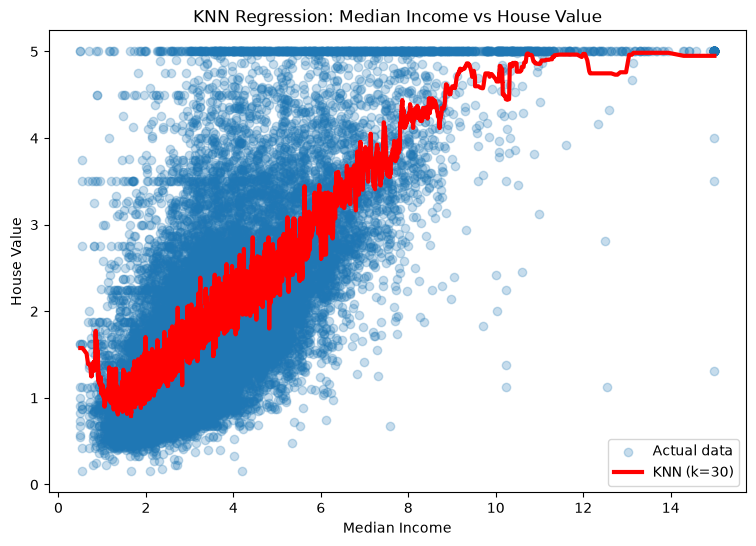

In [50]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor

# Select MedInc as the only input variable
X_knn = X[["MedInc"]]

# Create KNN regression model
knn_model = KNeighborsRegressor(n_neighbors=30)

# Fit the model
knn_model.fit(X_knn, y)

# Generate predictions
y_pred_knn = knn_model.predict(X_knn)

# Sort MedInc so the prediction curve is plotted correctly
sorted_idx = X["MedInc"].argsort()

# Plot actual data
plt.figure(figsize=(9, 6))

plt.scatter(
    X["MedInc"],
    y,
    alpha=0.25,
    label="Actual data"
)

# Plot KNN predictions
plt.plot(
    X["MedInc"].iloc[sorted_idx],
    y_pred_knn[sorted_idx],
    color="red",
    linewidth=3,
    label="KNN (k=30)"
)

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("KNN Regression: Median Income vs House Value")

plt.legend()
plt.savefig("figs/09_knn_medinc.png", dpi=150, bbox_inches="tight")
plt.show()

Mean HouseValue: 3.1675668023255814
Median HouseValue: 2.9524999999999997


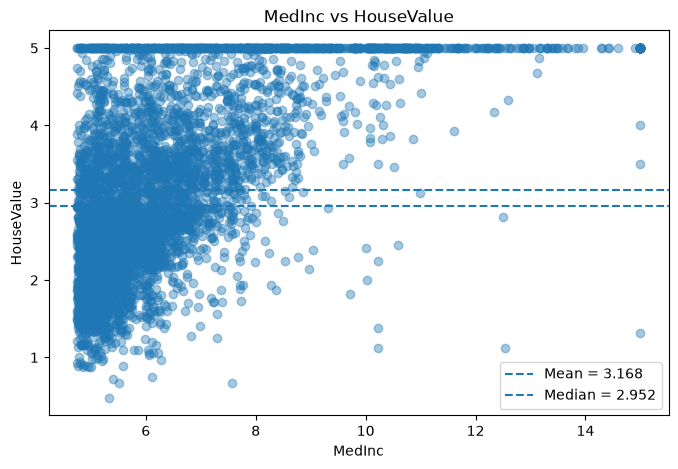


Prediction minimizing squared loss: 3.1682424248496996
Mean: 3.1675668023255814

Prediction minimizing absolute loss: 2.9506066733466936
Median: 2.9524999999999997


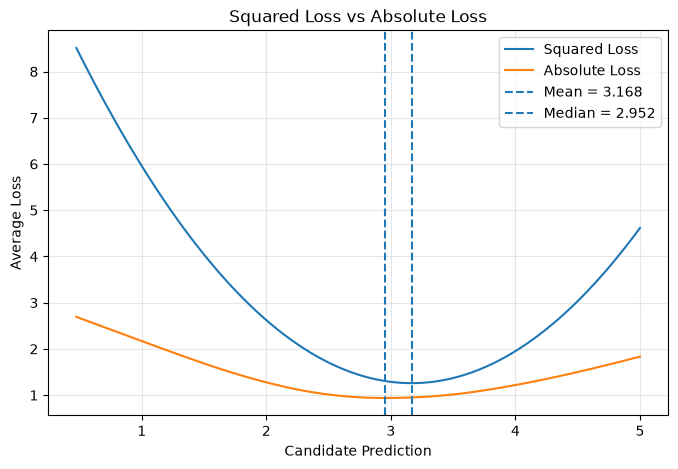

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Select a skewed subset
subset = X["MedInc"] > X["MedInc"].quantile(0.75)

medinc = X.loc[subset, "MedInc"]
houseval = y.loc[subset]

# Mean and median
mean_value = houseval.mean()
median_value = houseval.median()

print("Mean HouseValue:", mean_value)
print("Median HouseValue:", median_value)


# -------------------------------
# Plot MedInc vs HouseValue
# -------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(medinc, houseval, alpha=0.4)

plt.axhline(mean_value, linestyle="--", label=f"Mean = {mean_value:.3f}")
plt.axhline(median_value, linestyle="--", label=f"Median = {median_value:.3f}")

plt.xlabel("MedInc")
plt.ylabel("HouseValue")
plt.title("MedInc vs HouseValue")
plt.legend()
plt.savefig("figs/10_skewed_subset_medinc_vs_housevalue.png", dpi=150, bbox_inches="tight")
plt.show()


# -------------------------------
# Loss curves
# -------------------------------

predictions = np.linspace(houseval.min(), houseval.max(), 500)

squared_risk = []
absolute_risk = []

for p in predictions:
    squared_risk.append(np.mean((houseval - p) ** 2))
    absolute_risk.append(np.mean(np.abs(houseval - p)))

squared_risk = np.array(squared_risk)
absolute_risk = np.array(absolute_risk)


# Find minimum-risk predictions
squared_min = predictions[np.argmin(squared_risk)]
absolute_min = predictions[np.argmin(absolute_risk)]

print("\nPrediction minimizing squared loss:", squared_min)
print("Mean:", mean_value)

print("\nPrediction minimizing absolute loss:", absolute_min)
print("Median:", median_value)


# -------------------------------
# Plot loss curves
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(predictions, squared_risk, label="Squared Loss")
plt.plot(predictions, absolute_risk, label="Absolute Loss")

plt.axvline(mean_value, linestyle="--", label=f"Mean = {mean_value:.3f}")
plt.axvline(median_value, linestyle="--", label=f"Median = {median_value:.3f}")

plt.xlabel("Candidate Prediction")
plt.ylabel("Average Loss")
plt.title("Squared Loss vs Absolute Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("figs/11_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [52]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import NearestNeighbors


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


dimensions = range(1, X.shape[1] + 1)

nearest_distances = []
knn_errors = []
lr_errors = []


for d in dimensions:

    # Use first d features
    X_train_d = X_train_scaled[:, :d][::-1]
    X_test_d = X_test_scaled[:, :d][::-1]

    
    # -------------------------
    # Nearest-neighbor distance
    # -------------------------

    nn = NearestNeighbors(n_neighbors=50)
    nn.fit(X_train_d)

    distances, indices = nn.kneighbors(X_train_d)

    # First distance is distance to itself (0)
    # Second distance is actual nearest neighbor
    nearest_distance = distances[:, 1].mean()

    nearest_distances.append(nearest_distance)


    # -------------------------
    # kNN regression
    # -------------------------

    knn = KNeighborsRegressor(n_neighbors=50)

    knn.fit(X_train_d, y_train)

    y_pred_knn = knn.predict(X_test_d)

    knn_mse = mean_squared_error(y_test, y_pred_knn)

    knn_errors.append(knn_mse)


    # -------------------------
    # Linear regression
    # -------------------------

    lr = LinearRegression()

    lr.fit(X_train_d, y_train)

    y_pred_lr = lr.predict(X_test_d)

    lr_mse = mean_squared_error(y_test, y_pred_lr)

    lr_errors.append(lr_mse)


# Print results
print("Dimension | NN Distance | kNN MSE | LR MSE")

for d, dist, knn_err, lr_err in zip(
    dimensions,
    nearest_distances,
    knn_errors,
    lr_errors
):
    print(
        f"{d:9d} | "
        f"{dist:.4f}      | "
        f"{knn_err:.4f} | "
        f"{lr_err:.4f}"
    )

Dimension | NN Distance | kNN MSE | LR MSE
        1 | 0.0002      | 1.3336 | 1.3107
        2 | 0.0078      | 1.3327 | 1.3109
        3 | 0.0663      | 1.3396 | 1.3116
        4 | 0.1199      | 1.3373 | 1.3124
        5 | 0.2078      | 1.3340 | 1.3125
        6 | 0.2258      | 1.3318 | 1.3124
        7 | 0.3055      | 1.3328 | 1.3124
        8 | 0.3435      | 1.3307 | 1.3127


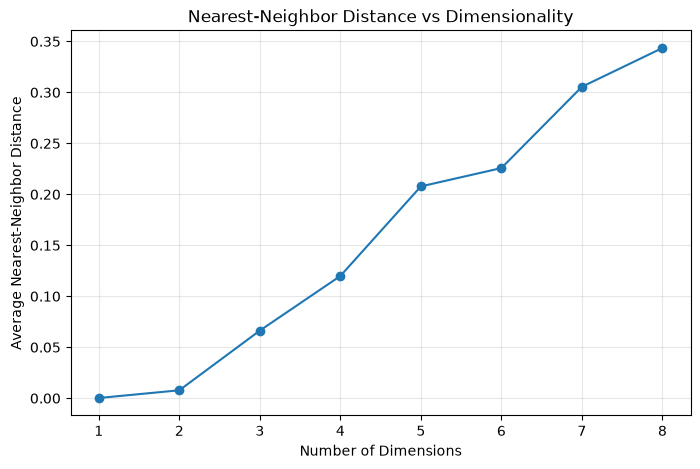

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    dimensions,
    nearest_distances,
    marker="o"
)

plt.xlabel("Number of Dimensions")
plt.ylabel("Average Nearest-Neighbor Distance")
plt.title("Nearest-Neighbor Distance vs Dimensionality")

plt.xticks(list(dimensions))
plt.grid(alpha=0.3)

plt.savefig("figs/12_nn_distance_vs_dimension.png", dpi=150, bbox_inches="tight")
plt.show()

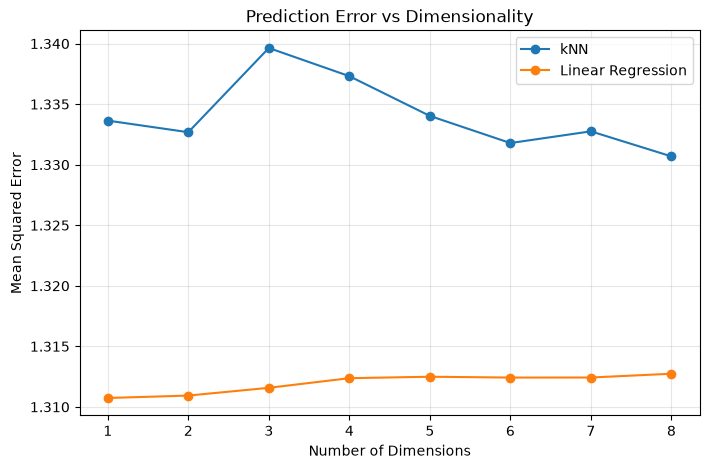

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    dimensions,
    knn_errors,
    marker="o",
    label="kNN"
)

plt.plot(
    dimensions,
    lr_errors,
    marker="o",
    label="Linear Regression"
)

plt.xlabel("Number of Dimensions")
plt.ylabel("Mean Squared Error")
plt.title("Prediction Error vs Dimensionality")

plt.xticks(list(dimensions))
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("figs/13_error_vs_dimension.png", dpi=150, bbox_inches="tight")
plt.show()

In [55]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error


# -------------------------------
# 1. Train-test split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# -------------------------------
# 2. Standardize features
# -------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# -------------------------------
# 3. Fit the models
# -------------------------------

lr = LinearRegression()

ridge = Ridge(alpha=1.0)

lasso = Lasso(alpha=0.01, max_iter=10000)


lr.fit(X_train_scaled, y_train)
ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)


# -------------------------------
# 4. Predictions
# -------------------------------

y_pred_lr = lr.predict(X_test_scaled)
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)


# -------------------------------
# 5. Calculate MSE
# -------------------------------

lr_mse = mean_squared_error(y_test, y_pred_lr)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)


print("Prediction Performance")
print("----------------------")
print("Linear Regression MSE:", lr_mse)
print("Ridge Regression MSE :", ridge_mse)
print("Lasso Regression MSE :", lasso_mse)

Prediction Performance
----------------------
Linear Regression MSE: 0.5558915986952444
Ridge Regression MSE : 0.5558548589435969
Lasso Regression MSE : 0.5482548967938964


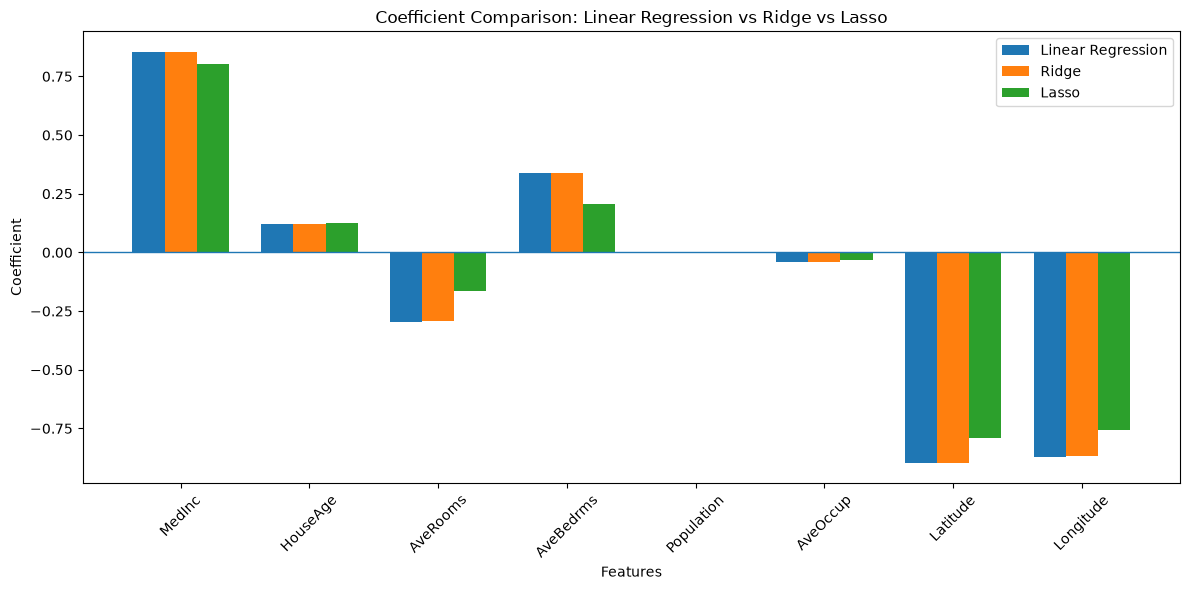

In [56]:
# -------------------------------
# 6. Coefficient comparison
# -------------------------------

features = X.columns

x_pos = np.arange(len(features))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x_pos - width,
    lr.coef_,
    width,
    label="Linear Regression"
)

plt.bar(
    x_pos,
    ridge.coef_,
    width,
    label="Ridge"
)

plt.bar(
    x_pos + width,
    lasso.coef_,
    width,
    label="Lasso"
)

plt.axhline(0, linewidth=1)

plt.xticks(x_pos, features, rotation=45)

plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.title("Coefficient Comparison: Linear Regression vs Ridge vs Lasso")

plt.legend()
plt.tight_layout()

plt.savefig("figs/14_coefficient_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [75]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ============================================================
# 1. Select only the 3 important features
# ============================================================

features = ["MedInc", "Latitude", "Longitude"]

X_3 = X[features]
y_3 = y


# ============================================================
# 2. Train-test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_3,
    y_3,
    test_size=0.2,
    random_state=42
)


# ============================================================
# 3. Scale the features
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# 4. Linear Regression
# ============================================================

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)


# ============================================================
# 5. KNN Regression
# ============================================================

knn_model = KNeighborsRegressor(
    n_neighbors=20
)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)


# ============================================================
# 6. Calculate metrics
# ============================================================

# ----- Linear Regression -----

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)


# ----- KNN -----

mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)


# ============================================================
# 7. Print results
# ============================================================

print("=" * 50)
print("LINEAR REGRESSION")
print("=" * 50)

print("MSE  :", mse_lr)
print("R²   :", r2_lr)


print("\n" + "=" * 50)
print("KNN (k=50)")
print("=" * 50)

print("MSE  :", mse_knn)
print("R²   :", r2_knn)


# ============================================================
# 8. Compare them
# ============================================================

print("\n" + "=" * 50)
print("COMPARISON")
print("=" * 50)

print(f"LR  R²   : {r2_lr:.4f}")
print(f"KNN R²   : {r2_knn:.4f}")



LINEAR REGRESSION
MSE  : 0.5607828191411723
R²   : 0.5720551152709819

KNN (k=50)
MSE  : 0.34825856547065154
R²   : 0.7342367373442787

COMPARISON
LR  R²   : 0.5721
KNN R²   : 0.7342
